In [11]:
import argparse
import os.path as osp
import random
from time import perf_counter as t

import numpy as np


import torch



device = torch.device('cpu')

# Paths
DATA_PATH = '../../../../my-coles-gnn-experimetns/scenario_gender/data/graphs/weighted/'
COLES_MODEL_PATH = '../../../../my-coles-gnn-experimetns/scenario_gender/data/orig_coles_embs.npy'

In [13]:
coles_embs = np.load(COLES_MODEL_PATH)
train_node_labels = torch.load(DATA_PATH + 'train_node_labels.pt').numpy()
train_node_labeled_ids = torch.load(DATA_PATH + 'train_node_labeled_ids.pt').numpy()

FileNotFoundError: [Errno 2] No such file or directory: '../../../../my-coles-gnn-experimetns/scenario_gender/data/graphs/weighted/train_node_labels.pt'

In [7]:
len(coles_embs)

7560

In [8]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# Assuming embeddings is a numpy array of shape (n_samples, n_features)
# And labels is a numpy array of shape (n_samples,) containing label ids

def plot_embeddings(embeddings, labels):
    # Step 1: Reduce dimensionality to 2D using t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    # Step 2: Plot the 2D embeddings with color based on labels
    plt.figure(figsize=(10, 8))
    
    # Create a scatter plot, with color based on labels
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels, cmap='Spectral', s=50, alpha=0.8)
    
    # Adding a color bar for reference
    plt.colorbar(scatter, ticks=np.unique(labels))

    # Adding title and labels
    plt.title('2D Embedding Visualization')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    
    plt.show()

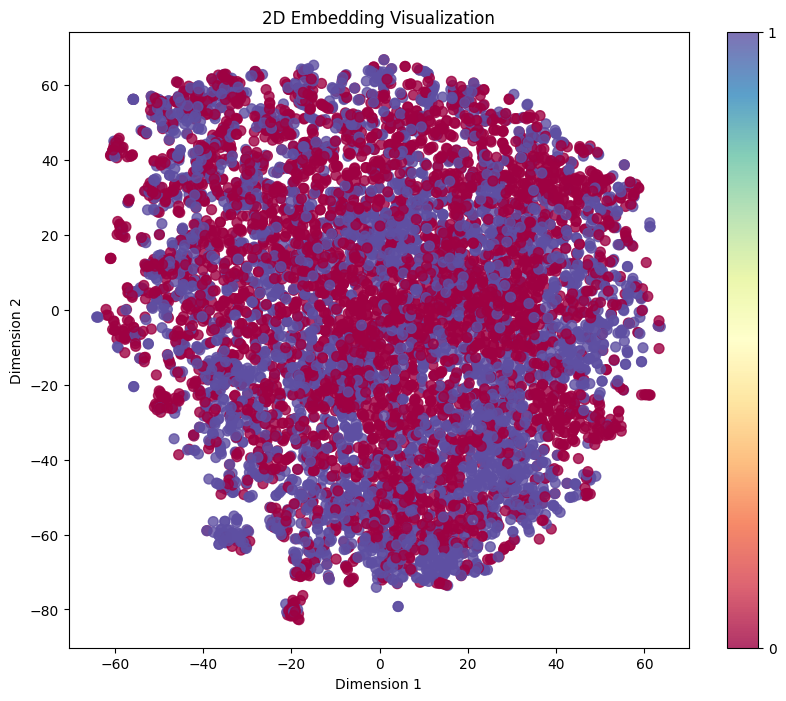

In [9]:
plot_embeddings(coles_embs, train_node_labels)

In [32]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

cosine_similarity(
    np.array([[1, 2, 3], [3, 4, 4]]),
    np.array([[4, 5, 5], [6, 7, 6]])
)


array([[1.        , 0.96000145],
       [0.96000145, 1.        ]])

In [10]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# Abstract similarity function
def compute_similarity(embeddings, method='cosine'):
    if method == 'cosine':
        # Cosine similarity (higher is more similar)
        similarity_matrix = cosine_similarity(embeddings)
    elif method == 'euclidean':
        # Euclidean distance (lower is more similar)
        similarity_matrix = -euclidean_distances(embeddings)
    elif method == 'dot':
        # Dot product (higher is more similar)
        similarity_matrix = np.dot(embeddings, embeddings.T)
    else:
        raise ValueError(f"Unknown method: {method}")
    
    return similarity_matrix

In [12]:
sim_coles_matr = compute_similarity(coles_embs, method='cosine')

In [30]:
print('min', sim_coles_matr.min())
print('max', (sim_coles_matr-np.eye(sim_coles_matr.shape[0])).max())
print('mean', sim_coles_matr.mean())
print('std', sim_coles_matr.std())

NameError: name 'sim_coles_matr' is not defined

In [16]:
def build_label_agreement_matrix(labels):
    """
    Create a binary matrix where entry (i, j) is 1 if labels[i] == labels[j], else 0.
    """
    n = len(labels)
    agreement_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            agreement_matrix[i, j] = 1 if labels[i] == labels[j] else 0
    return agreement_matrix


label_agreement_matrix = build_label_agreement_matrix(train_node_labels)

In [17]:
from scipy.stats import pearsonr

def correlation_between_similarity_and_labels(similarity_matrix, label_agreement_matrix):
    """
    Calculate the Pearson correlation between similarity matrix and label agreement.
    """
    
    # Flatten both matrices to vectors
    similarity_vector = similarity_matrix.flatten()
    agreement_vector = label_agreement_matrix.flatten()
    
    # Calculate Pearson correlation
    correlation, _ = pearsonr(similarity_vector, agreement_vector)
    
    return correlation

In [18]:
correlation_between_similarity_and_labels(sim_coles_matr, label_agreement_matrix)

0.045241086210323495

## Graphs

In [20]:
import networkx as nx

In [21]:
G = nx.read_gml(DATA_PATH + 'train_graph.gml')

In [24]:
nx.adjacency_matrix(G)

<14344x14344 sparse array of type '<class 'numpy.float64'>'
	with 573328 stored elements in Compressed Sparse Row format>

In [26]:
n_users = 14344-184
n_items = 184

rows = train_node_labeled_ids
cols = np.arange(n_items) + n_users

graph_emb_matr = nx.adjacency_matrix(G).todense()

In [33]:
graph_adj_embs = graph_emb_matr[rows, :][:, cols]
graph_adj_embs.sum(1).min()

4.5514130420087895e-07

In [34]:
graph_adj_embs.sum(0).min()

0.2983216643333435

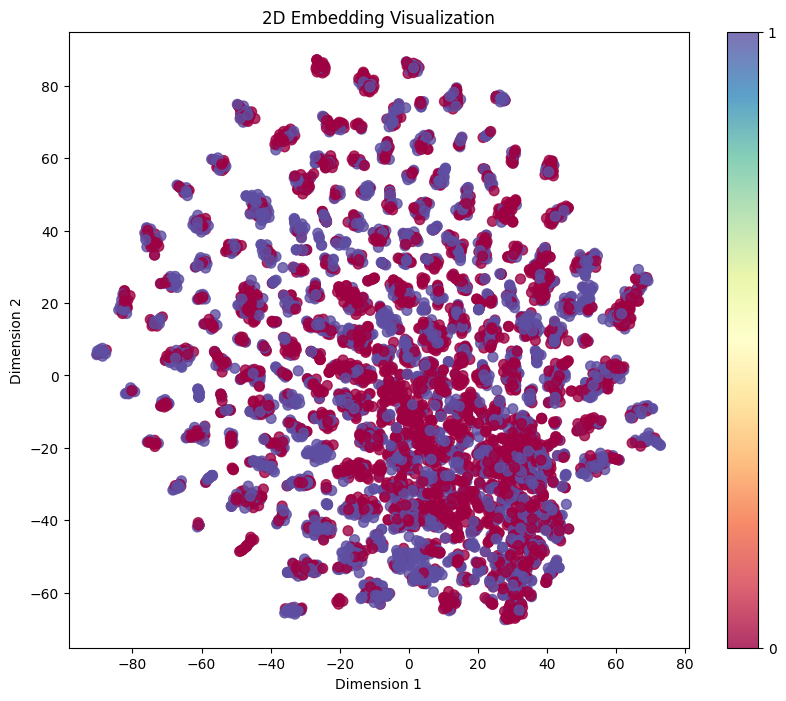

In [35]:
plot_embeddings(graph_adj_embs, train_node_labels)

In [40]:
sim_graph_matr = compute_similarity(graph_adj_embs, method='cosine')
print('min', sim_graph_matr.min())
print('max', sim_graph_matr.max())
print('mean', sim_graph_matr.mean())
print('std', sim_graph_matr.std())

print('CORR', correlation_between_similarity_and_labels(sim_graph_matr, label_agreement_matrix))

min 0.0
max 1.0000000000000007
mean 0.06298712820173787
std 0.1190955043957408
CORR 0.03391158081838872


In [41]:
sim_graph_matr = compute_similarity(graph_adj_embs, method='dot')
print('min', sim_graph_matr.min())
print('max', sim_graph_matr.max())
print('mean', sim_graph_matr.mean())
print('std', sim_graph_matr.std())

print('CORR', correlation_between_similarity_and_labels(sim_graph_matr, label_agreement_matrix))

min 0.0
max 0.2456733213011672
mean 8.231251336515343e-07
std 6.289175129588021e-05
CORR 0.001789885048262583


In [42]:
sim_graph_matr = compute_similarity(graph_adj_embs, method='euclidean')
print('min', sim_graph_matr.min())
print('max', sim_graph_matr.max())
print('mean', sim_graph_matr.mean())
print('std', sim_graph_matr.std())

print('CORR', correlation_between_similarity_and_labels(sim_graph_matr, label_agreement_matrix))

min -0.6752802038543381
max -0.0
mean -0.010660803922681697
std 0.02278557580289993
CORR 0.010610911296435797


In [43]:
graph_adj_embs_ones = graph_adj_embs.copy()
graph_adj_embs_ones[graph_adj_embs_ones != 0] = 1

In [44]:
sim_graph_matr = compute_similarity(graph_adj_embs_ones, method='cosine')
print('min', sim_graph_matr.min())
print('max', sim_graph_matr.max())
print('mean', sim_graph_matr.mean())
print('std', sim_graph_matr.std())

print('CORR', correlation_between_similarity_and_labels(sim_graph_matr, label_agreement_matrix))

min 0.0
max 1.0000000000000018
mean 0.46004962673179634
std 0.1200433631471605
CORR 0.051870867085104556


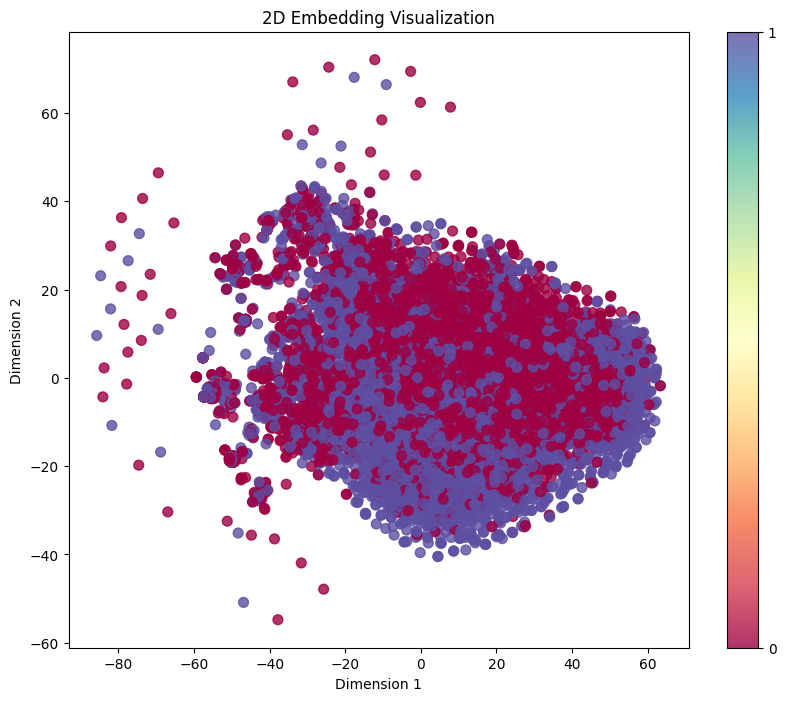

In [45]:
plot_embeddings(graph_adj_embs_ones, train_node_labels)

In [92]:
# пробуем что-то умнее

import numpy as np


def get_neighbors(similarity_matrix):
    res = []
    n = len(similarity_matrix)
    for i in range(n):
        # Sort indices of neighbors by similarity (excluding the point itself)
        neighbors = np.argsort(-similarity_matrix[i, :])
        neighbors = neighbors[neighbors != i]
        res.append(neighbors)
    return res


def precision_at_k(neighbors, labels, k=5):
    n = len(labels)
    precisions = []
    
    for i in range(n):
        # Check top K neighbors
        top_k_neighbors = neighbors[i][:k]
        same_label_count = sum(labels[top_k_neighbors] == labels[i])
        
        # Precision for this point
        precisions.append(same_label_count / k)
    
    # Average precision across all points
    return np.mean(precisions)



# def recall_at_k(neighbors, labels, k=5):
#     n = len(labels)
#     recall_scores = []
#     
#     for i in range(n):
#         # Check top K neighbors
#         top_k_neighbors = neighbors[i][:k]
#         
#         # Count how many of the top K neighbors have the same label
#         relevant_count_in_k = sum(labels[top_k_neighbors] == labels[i])
#         
#         # Total relevant items in the dataset for the label of point i
#         total_relevant = min(sum(labels == labels[i]) - 1, k)  # Exclude the point itself
#         
#         # Calculate recall for this point
#         if total_relevant > 0:  # Avoid division by zero
#             recall = relevant_count_in_k / total_relevant
#         else:
#             recall = 0
#         
#         recall_scores.append(recall)
#     
#     # Return the average Recall@K across all points
#     return np.mean(recall_scores)

In [82]:
sim_graph_matr = compute_similarity(graph_adj_embs, method='cosine')
neighbors_graph = get_neighbors(sim_graph_matr)

sim_graph_matr_ones = compute_similarity(graph_adj_embs_ones, method='cosine')
neighbors_graph_ones = get_neighbors(sim_graph_matr_ones)

sim_coles_matr = compute_similarity(coles_embs, method='cosine')
neighbors_coles = get_neighbors(sim_coles_matr)

[array([4648, 2012, 4280, ..., 7057, 2226,   55]),
 array([1678, 1401, 3845, ..., 6000,  671,   55]),
 array([5439, 6999, 5583, ..., 5299, 2226,   55]),
 array([2258, 5179, 5411, ..., 2226, 3985,   55]),
 array([5977, 2052,  673, ..., 4217, 5299,   55]),
 array([ 152, 1569, 5544, ..., 7057, 3985,   55]),
 array([5198, 5381, 3925, ..., 5299, 6542,   55]),
 array([5611, 6730, 7237, ..., 3845,   55, 2300]),
 array([1775, 3911, 7047, ..., 1944, 7057,   55]),
 array([3447, 1701, 5748, ..., 5299, 1635,   55]),
 array([7167,  765, 1948, ...,  320, 7057,   55]),
 array([4545, 4318,  643, ...,   55,  910, 4602]),
 array([  24, 1585, 5954, ..., 7080,   55, 1944]),
 array([5868, 3601, 4654, ..., 5297, 5299,   55]),
 array([5101,  555, 5781, ...,   55, 1944,  910]),
 array([1709, 5419, 1115, ..., 7057,  769,   55]),
 array([2303,  946, 7317, ..., 7057,   55,  910]),
 array([4860, 1775, 3911, ..., 1635, 2226,   55]),
 array([5023, 1630, 7555, ..., 2300,   55, 3845]),
 array([6195, 5251, 5425, ..., 

In [85]:
print(precision_at_k(neighbors_graph, train_node_labels, k=5))
print(precision_at_k(neighbors_graph_ones, train_node_labels, k=5))
print(precision_at_k(neighbors_coles, train_node_labels, k=5))

0.5923280423280424
0.640079365079365
0.6481216931216931


In [93]:
print(precision_at_k(neighbors_graph, train_node_labels, k=10))
print(precision_at_k(neighbors_graph_ones, train_node_labels, k=10))
print(precision_at_k(neighbors_coles, train_node_labels, k=10))

0.585515873015873
0.6360582010582011
0.640595238095238


In [94]:
print(precision_at_k(neighbors_graph, train_node_labels, k=20))
print(precision_at_k(neighbors_graph_ones, train_node_labels, k=20))
print(precision_at_k(neighbors_coles, train_node_labels, k=20))

0.5776124338624339
0.6271031746031746
0.6343981481481481


In [122]:
import numpy as np

def average_difference_between_neighbor_lists(list_1, list_2, k=10):
    """
    Calculate the average difference between two lists of top-k neighbors for each point.
    
    Parameters:
    - list_1: 2D numpy array (n_points x k) where each row contains indices of top-k neighbors for a point.
    - list_2: 2D numpy array (n_points x k) similar to list_1.
    - k: Integer, the number of top neighbors considered.
    
    Returns:
    - avg_difference: The average difference between the two lists of neighbors.
    """
    n_points = len(list_1)
    total_difference = 0
    
    for i in range(n_points):
        list1_slice = list_1[i][:k]
        list2_slice = list_2[i][:k]
        # Compute the difference for the i-th point
        # difference = len(set(list1_slice) - set(list2_slice)) + len(set(list2_slice) - set(list1_slice))
        
        difference = len(set(list1_slice) - set(list2_slice))
        # Sum up the total difference
        total_difference += difference / k
    
    # Calculate the average difference
    avg_difference = total_difference / n_points
    
    return avg_difference

In [123]:
print('W-O', average_difference_between_neighbor_lists(neighbors_graph, neighbors_graph_ones, k=10))
print('C-W', average_difference_between_neighbor_lists(neighbors_graph, neighbors_coles, k=10))
print('C-O', average_difference_between_neighbor_lists(neighbors_graph_ones, neighbors_coles, k=10))

W-O 0.9626322751322542
C-W 0.9703571428571305
C-O 0.9811507936507791


In [124]:
print('W-O', average_difference_between_neighbor_lists(neighbors_graph, neighbors_graph_ones, k=20))
print('C-W', average_difference_between_neighbor_lists(neighbors_graph, neighbors_coles, k=20))
print('C-O', average_difference_between_neighbor_lists(neighbors_graph_ones, neighbors_coles, k=20))

W-O 0.9513888888888467
C-W 0.9614814814814568
C-O 0.9711243386242989


In [125]:
print('W-O', average_difference_between_neighbor_lists(neighbors_graph, neighbors_graph_ones, k=5))
print('C-W', average_difference_between_neighbor_lists(neighbors_graph, neighbors_coles, k=5))
print('C-O', average_difference_between_neighbor_lists(neighbors_graph_ones, neighbors_coles, k=5))

W-O 0.97039682539684
C-W 0.9786243386243493
C-O 0.9873280423280493


In [126]:
print('W-O', average_difference_between_neighbor_lists(neighbors_graph, neighbors_graph_ones, k=3))
print('C-W', average_difference_between_neighbor_lists(neighbors_graph, neighbors_coles, k=3))
print('C-O', average_difference_between_neighbor_lists(neighbors_graph_ones, neighbors_coles, k=3))

W-O 0.9753527336860728
C-W 0.982671957671962
C-O 0.9904761904761933


In [127]:
print('W-O', average_difference_between_neighbor_lists(neighbors_graph, neighbors_graph_ones, k=1))
print('C-W', average_difference_between_neighbor_lists(neighbors_graph, neighbors_coles, k=1))
print('C-O', average_difference_between_neighbor_lists(neighbors_graph_ones, neighbors_coles, k=1))

W-O 0.9850529100529101
C-W 0.9899470899470899
C-O 0.9965608465608465


In [128]:
print('W-O', average_difference_between_neighbor_lists(neighbors_graph, neighbors_graph_ones, k=100))
print('C-W', average_difference_between_neighbor_lists(neighbors_graph, neighbors_coles, k=100))
print('C-O', average_difference_between_neighbor_lists(neighbors_graph_ones, neighbors_coles, k=100))

W-O 0.8943293650793436
C-W 0.9182142857142508
C-O 0.9286256613756285


In [129]:
print('W-O', average_difference_between_neighbor_lists(neighbors_graph, neighbors_graph_ones, k=1000))
print('C-W', average_difference_between_neighbor_lists(neighbors_graph, neighbors_coles, k=1000))
print('C-O', average_difference_between_neighbor_lists(neighbors_graph_ones, neighbors_coles, k=1000))

W-O 0.6219082010582025
C-W 0.7386638888888867
C-O 0.7256968253968278


In [ ]:
average_difference_between_neighbor_lists(neighbors_graph, neighbors_coles)

In [ ]:
average_difference_between_neighbor_lists(neighbors_graph_ones, neighbors_coles)

In [ ]:
average_difference_between_neighbor_lists(neighbors_graph, neighbors_coles)

In [46]:
from sklearn.model_selection import train_test_split

train_ids, test_ids, _, _ = \
    train_test_split(range(len(train_node_labeled_ids)), train_node_labeled_ids, test_size=0.3, random_state=42)

In [51]:
y_train = train_node_labels[train_ids]
y_test = train_node_labels[test_ids]

X_train_graph = graph_adj_embs[train_ids, :]
X_test_graph = graph_adj_embs[test_ids, :]

X_train_coles = coles_embs[train_ids, :]
X_test_coles = coles_embs[test_ids, :]

X_train_graph_one = graph_adj_embs_ones[train_ids, :]
X_test_graph_one = graph_adj_embs_ones[test_ids, :]

In [67]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
import lightgbm as lgb


def train_clf(X_train, y_train, X_test, y_test):
    clf = lgb.LGBMClassifier(
        objective='binary',
        boosting_type='gbdt',
        num_leaves=31,
        learning_rate=0.05,
        n_estimators=100,
        max_depth=-1,
        random_state=42,
        verbosity=-1
    )
    
    clf.fit(X_train, y_train)

    y_pred_proba = clf.predict_proba(X_test)
    y_pred = np.argmax(y_pred_proba, axis=1)

    micro = f1_score(y_test, y_pred, average="micro")
    macro = f1_score(y_test, y_pred, average="macro")
    auc = roc_auc_score(y_test, y_pred_proba[:, 1])
    acc = accuracy_score(y_test, y_pred)
    
    # print(f'F1Mi: {micro}, F1Macro: {macro}, Acc: {acc}, AUC: {auc}')
    return {
        'F1Mi': micro,
        'F1Ma': macro,
        'auc': auc,
        'acc': acc
    }

In [49]:
train_clf(X_train_graph, y_train, X_test_graph, y_test)

F1Mi: 0.7627865961199295, F1Macro: 0.7543628246753247, Acc: 0.7627865961199295, AUC: 0.8492141446093645


In [50]:
train_clf(X_train_coles, y_train, X_test_coles, y_test)

F1Mi: 0.7729276895943563, F1Macro: 0.7681071374328827, Acc: 0.7729276895943563, AUC: 0.8604072868651798


In [53]:
train_clf(X_train_graph_one, y_train, X_test_graph_one, y_test)

F1Mi: 0.7438271604938271, F1Macro: 0.7352161932490084, Acc: 0.7438271604938271, AUC: 0.8249280072339339


(5292, 1024)

In [55]:
np.hstack((X_train_graph_one, X_train_coles)).shape

(5292, 1208)

In [60]:
cur_train = np.hstack((X_train_graph_one, X_train_coles))
cur_test = np.hstack((X_test_graph_one, X_test_coles))
train_clf(cur_train, y_train, cur_test, y_test)

F1Mi: 0.7746913580246914, F1Macro: 0.7695425821496259, Acc: 0.7746913580246914, AUC: 0.8623685777569133


In [61]:
cur_train = np.hstack((X_train_graph, X_train_coles))
cur_test = np.hstack((X_test_graph, X_test_coles))
train_clf(cur_train, y_train, cur_test, y_test)

F1Mi: 0.7768959435626103, F1Macro: 0.7724219168302695, Acc: 0.7768959435626103, AUC: 0.8645638057550104


In [68]:
import functools


def repeat(n_times):
    def decorator(f):
        @functools.wraps(f)
        def wrapper(*args, **kwargs):
            results = [f(*args, **kwargs) for _ in range(n_times)]
            statistics = {}
            for model in results[0].keys():
                model_values = [r[model] for r in results]
                for metric in model_values[0].keys():
                    metric_vals = [r[metric] for r in model_values]
                    statistics[model + '_' + metric] = {
                        'mean': np.mean(metric_vals),
                        'std': np.std(metric_vals)}
            # print_statistics(statistics, f.__name__)
            return statistics
        return wrapper
    return decorator

In [75]:
@repeat(5)
def pipeline():
    train_ids, test_ids, _, _ = \
        train_test_split(range(len(train_node_labeled_ids)), train_node_labeled_ids, test_size=0.3)
    
    y_train = train_node_labels[train_ids]
    y_test = train_node_labels[test_ids]
    
    X_train_graph = graph_adj_embs[train_ids, :]
    X_test_graph = graph_adj_embs[test_ids, :]
    
    X_train_coles = coles_embs[train_ids, :]
    X_test_coles = coles_embs[test_ids, :]
    
    X_train_graph_one = graph_adj_embs_ones[train_ids, :]
    X_test_graph_one = graph_adj_embs_ones[test_ids, :]
    
    colW_train = np.hstack((X_train_graph, X_train_coles))
    colW_test = np.hstack((X_test_graph, X_test_coles))
    
    colO_train = np.hstack((X_train_graph_one, X_train_coles))
    colO_test = np.hstack((X_test_graph_one, X_test_coles))
    
    colG_train = np.hstack((X_train_graph_one, X_train_graph, X_train_coles))
    colG_test = np.hstack((X_test_graph_one, X_test_graph, X_test_coles))
    
    res = {
        'GraphW': train_clf(X_train_graph, y_train, X_test_graph, y_test),
        'GraphO': train_clf(X_train_graph_one, y_train, X_test_graph_one, y_test),
        'CoLES': train_clf(X_train_coles, y_train, X_test_coles, y_test),
        'CoLES+W': train_clf(colW_train, y_train, colW_test, y_test),
        'CoLES+O': train_clf(colO_train, y_train, colO_test, y_test),
        'CoLES+G': train_clf(colG_train, y_train, colG_test, y_test)
    }
    return res

In [76]:
mertics = pipeline()

In [78]:
def print_metrics(metrics):
    for metric_name in ['F1Mi', 'F1Ma', 'auc', 'acc']:
        for metric in metrics:
            if metric_name == metric.split('_')[-1]:
                print(f'{metric}: {metrics[metric]}')

In [79]:
print_metrics(mertics)

GraphW_F1Mi: {'mean': 0.7733686067019401, 'std': 0.006640158940746611}
GraphO_F1Mi: {'mean': 0.7516754850088183, 'std': 0.008771480423850585}
CoLES_F1Mi: {'mean': 0.780246913580247, 'std': 0.006313588119812599}
CoLES+W_F1Mi: {'mean': 0.7861552028218696, 'std': 0.008067698773532785}
CoLES+O_F1Mi: {'mean': 0.7890652557319224, 'std': 0.005324701636490492}
CoLES+G_F1Mi: {'mean': 0.785978835978836, 'std': 0.007781156408626381}
GraphW_F1Ma: {'mean': 0.7647624784256737, 'std': 0.0069826418220742805}
GraphO_F1Ma: {'mean': 0.7414621066896357, 'std': 0.009189856696223074}
CoLES_F1Ma: {'mean': 0.7746749629209088, 'std': 0.007727515631463131}
CoLES+W_F1Ma: {'mean': 0.780794103597205, 'std': 0.00920957296909409}
CoLES+O_F1Ma: {'mean': 0.7839149399670292, 'std': 0.006316363946316606}
CoLES+G_F1Ma: {'mean': 0.7806240930303708, 'std': 0.008927808452383626}
GraphW_auc: {'mean': 0.8560087735318938, 'std': 0.005657088944391939}
GraphO_auc: {'mean': 0.8269868568043887, 'std': 0.00861335824410949}
CoLES_au